# 2.6 Inhomogeneous Equation System

> Using Gaussian elimination, find all solutions of the inhomogeneous equation system $\boldsymbol{A} x = \boldsymbol{b}$ with:

> $$
    \begin{align}
        \boldsymbol{A} &=
        \begin{bmatrix}
            0 & 1 & 0 & 0 & 1 & 0\\
            0 & 0 & 0 & 1 & 1 & 0\\
            0 & 1 & 0 & 0 & 0 & 1\\
        \end{bmatrix},
        &
        \boldsymbol{b} &= 
        \begin{bmatrix}
            2\\
            -1\\
            1\\
        \end{bmatrix}
    \end{align}
$$


$$
    \begin{align}
        \left[
        \begin{array}{cccccc|c}
            0 & 1 & 0 & 0 & 1 & 0 & 2\\
            0 & 0 & 0 & 1 & 1 & 0 & -1\\
            0 & 1 & 0 & 0 & 0 & 1 & 1\\
        \end{array}
        \right]
        &\leadsto
        \left[
        \begin{array}{cccccc|c}
            0 & 1 & 0 & 0 & 0 & 1 & 1\\
            0 & 0 & 0 & 1 & 0 & 1 & -2\\
            0 & 0 & 0 & 0 & 1 & -1 & 1\\
        \end{array}
        \right]
        && \text{Reduced Row-Echelon Form}\\
        &\leadsto
        \left[
        \begin{array}{cccccc|c}
            -1 & 0 & 0 & 0 & 0 & 0 & 0\\
            0 & 1 & 0 & 0 & 0 & 1 & 1\\
            0 & 0 & -1 & 0 & 0 & 0 & 0\\
            0 & 0 & 0 & 1 & 0 & 1 & -2\\
            0 & 0 & 0 & 0 & 1 & -1 & 1\\
            0 & 0 & 0 & 0 & 0 & -1 & 0\\
        \end{array}
        \right]
        && \text{Minus-1 Trick}
        \\
    \end{align}
$$

$$
    \mathcal{S} = \left\{
        \begin{pmatrix}
            0 \\
            1 \\
            0 \\
            -2 \\
            1\\
            0
        \end{pmatrix}
        + \lambda_1
        \begin{pmatrix}
            -1 \\
            0 \\
            0 \\
            0 \\
            0 \\
            0
        \end{pmatrix}
        + \lambda_3
        \begin{pmatrix}
            0 \\
            0 \\
            -1 \\
            0 \\
            0 \\
            0
        \end{pmatrix}
        + \lambda_6
        \begin{pmatrix}
            0 \\
            1 \\
            0 \\
            1 \\
            -1 \\
            -1
        \end{pmatrix}
    \right\}$$

In [17]:
import numpy as np

A = np.array([
    [0, 1, 0, 0, 1, 0],
    [0, 0, 0, 1, 1, 0],
    [0, 1, 0, 0, 0, 1]
])

b = np.array([
    [2],
    [-1],
    [1],
])

try:
    np.linalg.solve(A, b)
except np.linalg.LinAlgError as e:
    print(e)

Last 2 dimensions of the array must be square


In [27]:

def get_solution(lambda_1, lambda_3, lambda_6):
    x = (
        np.array([[0], [1], [0], [-2], [1], [0]])
        + lambda_1 * np.array([[-1], [0], [0], [0], [0], [0]])
        + lambda_3 * np.array([[0], [0], [-1], [0], [0], [0]])
        + lambda_6 * np.array([[0], [1], [0], [1], [-1], [-1]])
    )
    return x


def check_solution(x):
    return np.all(A @ x == b)

In [30]:
points = []

for l1 in np.linspace(-10, 10, 11):
    for l2 in np.linspace(-10, 10, 11):
        for l3 in np.linspace(-10, 10, 11):
            x = get_solution(l1, l2, l3)
            points.append(x)
            assert check_solution(x)

points = np.array(points)

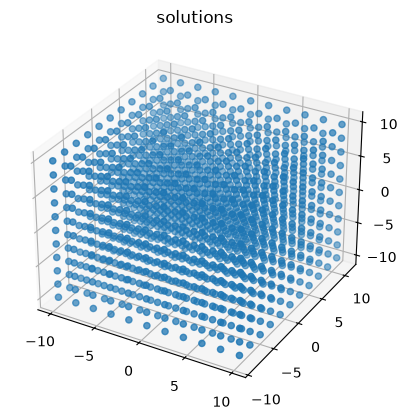

In [34]:
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(points[:, 0], points[:, 1], points[:, 2])
ax.set_title("solutions")
plt.show()